# Manuscript benchmark: 2D triangle L1 (with L2 pre) on every section of the real DVF

This notebook applies the per-slice **cluster** correction recipe to every z-slice of the real registration field at `data/corrected_correspondences_count_touching/registered_output/deformation3d.npy`.

The actual solver code lives in two sibling files:

- [`_run_2d_clusters.py`](_run_2d_clusters.py) -- main runner, slice loop, parallel pool, CSV / log / checkpoint.
- [`_bench_worker.py`](_bench_worker.py) -- the per-cluster worker (`solve_cluster_inline`, `_make_2tri_jac_2d`). Lives in its own file so Windows `multiprocessing.spawn` can re-import it inside each child process.

Algorithm overview (see [`WRITEUP_2d_clusters.md`](WRITEUP_2d_clusters.md) for the full justification):

1. For each slice in ascending order of initial fold count:
    1. Detect cell-fold mask (cells where `min(T1, T2) <= 0`).
    2. Dilate by `MERGE_DILATION` cells and connected-component label to get clusters.
    3. Build each cluster's crop: bbox + `BBOX_PAD` cells of padding, rectangular interior mask.
    4. Partition clusters into non-conflicting rounds (strict 1-cell gap between same-round bboxes).
    5. Solve each cluster in parallel via a `ProcessPoolExecutor`: L2 multi-pass + L1 polish with analytical Jacobian.
    6. Splice each cluster's *interior* corners back into the slice.
    7. Repeat until `n_neg = 0` or the slice timeout fires.

Output goes to `notebooks/manuscript/output/2d_real_full/`:

- `per_slice.csv` -- one row per slice (init/final fold count, min_tri, L1/L2 norms, time, feasibility).
- `per_cluster.csv` -- one row per cluster solve across all outer iters.
- `run.log` -- structured progress log.
- `checkpoint.npz` -- snapshot of the corrected `(3, D, H, W)` volume.

Companion notebook: [`04_benchmark_3d_real_full.ipynb`](04_benchmark_3d_real_full.ipynb) runs the same recipe with the 6-tet constraint on the full 3D volume.

## Setup

Importing `_run_2d_clusters` as `runner` gives the notebook access to the exact same code path as `python _run_2d_clusters.py`. The runner exposes `process_one_slice` (single-slice solve), `enumerate_clusters_2d`, and `main` (the full resumable 528-slice loop).

In [1]:
import os, sys, time, json
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

sys.path.insert(0, os.path.abspath('../..'))
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dvfopt.jacobian.triangle_sign import _triangle_areas_2d

import _run_2d_clusters as runner

OUTPUT_DIR = runner.OUTPUT_DIR
CSV_PATH = runner.SLICE_CSV_PATH
CLUSTER_CSV_PATH = runner.CLUSTER_CSV_PATH
CKPT_PATH = runner.CKPT_PATH
DATA_PATH = runner.DATA_PATH

print(f'THRESHOLD             = {runner.THRESHOLD}')
print(f'EPS_L1                = {runner.EPS_L1}')
print(f'MERGE_DILATION        = {runner.MERGE_DILATION}  (density-aware via _merge_for_n_neg)')
print(f'BBOX_PAD              = {runner.BBOX_PAD}')
print(f'MAX_CLUSTER_CELLS     = {runner.MAX_CLUSTER_CELLS}')
print(f'L2_MAX_PASSES         = {runner.L2_MAX_PASSES}')
print(f'L2_PASS_TIMEOUT_S     = {runner.L2_PASS_TIMEOUT_S}')
print(f'L1_POLISH_TIMEOUT_S   = {runner.L1_POLISH_TIMEOUT_S}')
print(f'PER_CLUSTER_TIMEOUT_S = {runner.PER_CLUSTER_TIMEOUT_S}')
print(f'MAX_SLICE_TIME_S      = {runner.MAX_SLICE_TIME_S}')
print(f'N_PARALLEL_WORKERS    = {runner.N_PARALLEL_WORKERS}')
print(f'OUTPUT_DIR            = {OUTPUT_DIR}')

THRESHOLD             = 0.01
EPS_L1                = 0.0001
MERGE_DILATION        = 2  (density-aware via _merge_for_n_neg)
BBOX_PAD              = 1
MAX_CLUSTER_CELLS     = 2000
L2_MAX_PASSES         = 15
L2_PASS_TIMEOUT_S     = 3600
L1_POLISH_TIMEOUT_S   = 3600
PER_CLUSTER_TIMEOUT_S = 3600
MAX_SLICE_TIME_S      = 28800
N_PARALLEL_WORKERS    = 22
OUTPUT_DIR            = c:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\notebooks\manuscript\output\2d_real_full


## Load the real DVF and survey folds per slice

In [2]:
phi_full = np.load(DATA_PATH)   # (3, D, H, W) with [dz, dy, dx]
D, H, W = phi_full.shape[1:]
print(f'deformation3d.npy shape : {phi_full.shape}  (D={D}, H={H}, W={W})')
print(f'channel ranges:')
for c, name in enumerate(['dz', 'dy', 'dx']):
    print(f'  {name}: min={phi_full[c].min():+.3f}, max={phi_full[c].max():+.3f}, mean={phi_full[c].mean():+.3f}')
if not np.all(phi_full[0] == 0):
    print('NOTE: channel 0 (dz) is NOT identically zero -- per-slice 2D treatment is an approximation.')
else:
    print('Channel 0 (dz) is identically zero -- per-slice 2D treatment is exact.')

deformation3d.npy shape : (3, 528, 320, 456)  (D=528, H=320, W=456)
channel ranges:
  dz: min=+0.000, max=+0.000, mean=+0.000
  dy: min=-138.997, max=+22.999, mean=+0.100
  dx: min=-76.002, max=+26.001, mean=+0.003
Channel 0 (dz) is identically zero -- per-slice 2D treatment is exact.


Surveyed 528 slices in 8.8s
slices with folds : 528 / 528
total folded triangles across all slices: 470551
max folds in a single slice : 3257  (slice z=2)
global min triangle area    : -848.7306


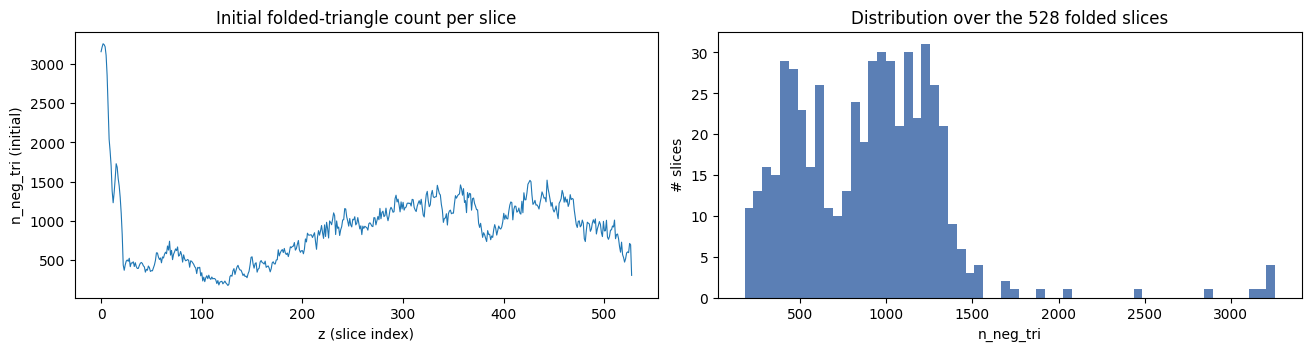

In [3]:
def slice_fold_stats(phi_full, z):
    """Return (n_neg_tri, min_tri) for slice z."""
    dy = phi_full[1, z]; dx = phi_full[2, z]
    T1, T2 = _triangle_areas_2d(dy, dx)
    n_neg = int((T1 <= 0).sum() + (T2 <= 0).sum())
    return n_neg, float(min(T1.min(), T2.min()))


t0 = time.time()
fold_per_slice = np.zeros(D, dtype=np.int64)
min_tri_per_slice = np.zeros(D, dtype=np.float64)
for z in range(D):
    n_neg, mt = slice_fold_stats(phi_full, z)
    fold_per_slice[z] = n_neg
    min_tri_per_slice[z] = mt
print(f'Surveyed {D} slices in {time.time()-t0:.1f}s')
print(f'slices with folds : {int((fold_per_slice > 0).sum())} / {D}')
print(f'total folded triangles across all slices: {int(fold_per_slice.sum())}')
print(f'max folds in a single slice : {int(fold_per_slice.max())}  (slice z={int(np.argmax(fold_per_slice))})')
print(f'global min triangle area    : {float(min_tri_per_slice.min()):+.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4), constrained_layout=True)
axes[0].plot(fold_per_slice, lw=0.8)
axes[0].set_xlabel('z (slice index)'); axes[0].set_ylabel('n_neg_tri (initial)')
axes[0].set_title('Initial folded-triangle count per slice')
axes[1].hist(fold_per_slice[fold_per_slice > 0], bins=60, color='#5b7fb5')
axes[1].set_xlabel('n_neg_tri'); axes[1].set_ylabel('# slices')
axes[1].set_title(f'Distribution over the {int((fold_per_slice>0).sum())} folded slices')
plt.show()

## Smoke test on a single slice

Calls `runner.process_one_slice(z, phi_full, phi_anchor, executor=pool)` -- the same function the full runner invokes per slice. The pool is a `ProcessPoolExecutor` with `runner.N_PARALLEL_WORKERS` workers; each cluster is dispatched as a future and `_bench_worker.solve_cluster_inline` runs the analytical-Jacobian SLSQP.

In [ ]:
# Pick a moderately hard slice as a single-slice demonstration.
folded_z = np.where(fold_per_slice > 0)[0]
order = folded_z[np.argsort(fold_per_slice[folded_z])]
SMOKE_Z = int(order[len(order) // 4])
print(f'Smoke-testing z={SMOKE_Z}  (init folds = {int(fold_per_slice[SMOKE_Z])})')

phi_demo = phi_full.copy()
phi_anchor = phi_full.copy()

ctx = mp.get_context('spawn')
with ProcessPoolExecutor(max_workers=runner.N_PARALLEL_WORKERS, mp_context=ctx) as ex:
    t0 = time.time()
    sr, _crows, _phi = runner.process_one_slice(SMOKE_Z, phi_demo, phi_anchor, executor=ex)
    wall = time.time() - t0

print(
    f'z={SMOKE_Z}: init={sr["init_n_neg_tri"]:>4d}  '
    f'final={sr["after_l1_n_neg_tri"]:>4d}  '
    f'min_tri={sr["after_l1_min_tri"]:+.4f}  '
    f'clusters={sr["n_clusters"]}  '
    f'feasible={sr["feasible"]}  '
    f'wall={wall:.1f}s'
)

Smoke-testing z=59  (init folds = 529)
    [z=59 outer=0 round=1/4]  +44 clusters | n_neg=164  feas_so_far=44 skip=0 to=0  elapsed=583s


## Full benchmark across all 528 slices

`runner.main()` runs the full resumable loop: scans every slice for its initial fold count, processes them in ascending fold-count order, writes `per_slice.csv` / `per_cluster.csv` / `run.log` row-by-row, and snapshots `checkpoint.npz` every `CHECKPOINT_EVERY=5` slices. On restart, any `z` already in `per_slice.csv` is skipped.

**The full run takes several hours.** For interactive work, prefer launching it externally:

```powershell
python notebooks/manuscript/_run_2d_clusters.py
```

Then re-enter this notebook below to load `per_slice.csv` and produce the aggregate stats / figures. Set `RUN_FULL_BENCHMARK = True` if you really do want the kernel to drive the run.

In [ ]:
RUN_FULL_BENCHMARK = False

if RUN_FULL_BENCHMARK:
    runner.main()
else:
    print('RUN_FULL_BENCHMARK=False -- skipping. '
          'Launch externally with `python notebooks/manuscript/_run_2d_clusters.py` '
          'and re-run the cells below to load results.')

## Aggregate stats

In [ ]:
df = pd.read_csv(CSV_PATH)
df_folded = df[df['init_n_neg_tri'] > 0].copy()
df_feasible = df_folded[df_folded['feasible']].copy()

print(f'total slices in CSV                     : {len(df)}')
print(f'slices with folds (work needed)         : {len(df_folded)}')
print(f'slices reaching feasibility             : {len(df_feasible)} / {len(df_folded)}'
      + (f'  ({100.0*len(df_feasible)/len(df_folded):.1f}%)' if len(df_folded) else ''))
print()
if len(df_feasible) > 0:
    print(f'L1 drop after polish (feasible slices only):')
    print(f'  mean = {df_feasible["l1_drop_pct"].mean():.2f}%   '
          f'median = {df_feasible["l1_drop_pct"].median():.2f}%   '
          f'max = {df_feasible["l1_drop_pct"].max():.2f}%')
    print(f'L2 phase wall time (feasible slices):')
    print(f'  total = {df_feasible["total_l2_t"].sum():.1f}s   '
          f'mean = {df_feasible["total_l2_t"].mean():.1f}s   '
          f'p95 = {df_feasible["total_l2_t"].quantile(0.95):.1f}s   '
          f'max = {df_feasible["total_l2_t"].max():.1f}s')
    print(f'L1 polish wall time (feasible slices):')
    print(f'  total = {df_feasible["total_l1_t"].sum():.1f}s   '
          f'mean = {df_feasible["total_l1_t"].mean():.1f}s   '
          f'p95 = {df_feasible["total_l1_t"].quantile(0.95):.1f}s   '
          f'max = {df_feasible["total_l1_t"].max():.1f}s')
    print(f'Slice wall time:')
    print(f'  total = {df["total_t"].sum():.1f}s = {df["total_t"].sum()/3600:.2f} h   '
          f'mean = {df_feasible["total_t"].mean():.1f}s   '
          f'p95 = {df_feasible["total_t"].quantile(0.95):.1f}s   '
          f'max = {df_feasible["total_t"].max():.1f}s')

In [ ]:
FIG_DIR = OUTPUT_DIR

# (1) per-slice fold overview
fig, ax = plt.subplots(figsize=(11, 3.5), constrained_layout=True)
ax.plot(df['z'], df['init_n_neg_tri'], lw=0.7, color='#c62828', label='initial n_neg_tri')
ax.plot(df['z'], df['after_l1_n_neg_tri'].clip(lower=0), lw=0.7, color='#1b8a3a',
         label='after L2+L1 (n_neg_tri)')
ax.set_yscale('symlog', linthresh=1)
ax.set_xlabel('z (slice index)'); ax.set_ylabel('n_neg_tri (symlog)')
ax.set_title('Folded triangles per slice: before vs after L2+L1')
ax.legend()
fig.savefig(os.path.join(FIG_DIR, 'per_slice_fold_overview.png'), dpi=200, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'per_slice_fold_overview.pdf'), bbox_inches='tight')
plt.show()

# (2) initial vs final L1-norm scatter (one point per feasible slice)
if len(df_feasible) > 0:
    fig, ax = plt.subplots(figsize=(6.5, 6), constrained_layout=True)
    lo = min(df_feasible['init_L1'].min(), df_feasible['after_l1_L1'].min()) * 0.95
    hi = max(df_feasible['init_L1'].max(), df_feasible['after_l1_L1'].max()) * 1.05
    ax.plot([lo, hi], [lo, hi], color='#888888', lw=1, linestyle='--')
    ax.scatter(df_feasible['init_L1'], df_feasible['after_l1_L1'],
                s=8, alpha=0.7, color='#1b8a3a')
    ax.set_xlabel('initial L1 norm of correction'); ax.set_ylabel('L1 norm after L2+L1')
    ax.set_title('Correction L1 norm: initial vs polished (one point per feasible slice)')
    ax.set_aspect('equal')
    fig.savefig(os.path.join(FIG_DIR, 'init_vs_final_l1.png'), dpi=200, bbox_inches='tight')
    fig.savefig(os.path.join(FIG_DIR, 'init_vs_final_l1.pdf'), bbox_inches='tight')
    plt.show()

# (3) time distribution
if len(df_folded) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
    axes[0].hist(df_folded['total_l2_t'], bins=60, color='#5b7fb5')
    axes[0].set_xlabel('L2 phase time (s)'); axes[0].set_ylabel('# slices')
    axes[0].set_title('L2 phase runtime per folded slice')
    axes[1].hist(df_folded['total_l1_t'], bins=60, color='#1b8a3a')
    axes[1].set_xlabel('L1 polish time (s)'); axes[1].set_ylabel('# slices')
    axes[1].set_title('L1 polish runtime per folded slice')
    fig.savefig(os.path.join(FIG_DIR, 'time_distribution.png'), dpi=200, bbox_inches='tight')
    fig.savefig(os.path.join(FIG_DIR, 'time_distribution.pdf'), bbox_inches='tight')
    plt.show()

# (4) worst-slice visual (init vs final triangle areas + correction magnitude)
if len(df_folded) > 0 and os.path.exists(CKPT_PATH):
    with np.load(CKPT_PATH) as data:
        corrected_full = data['phi_corrected']
    worst_z = int(df_folded.sort_values('init_n_neg_tri', ascending=False).iloc[0]['z'])
    phi_init_slice = np.stack([phi_full[1, worst_z].copy(),
                                 phi_full[2, worst_z].copy()])
    phi_l1_slice = np.stack([corrected_full[1, worst_z].copy(),
                               corrected_full[2, worst_z].copy()])
    res = np.linalg.norm(phi_l1_slice - phi_init_slice, axis=0)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    T1i, T2i = _triangle_areas_2d(phi_init_slice[0], phi_init_slice[1])
    T1f, T2f = _triangle_areas_2d(phi_l1_slice[0], phi_l1_slice[1])
    init_min = np.minimum(T1i, T2i)
    final_min = np.minimum(T1f, T2f)
    vmax = max(abs(init_min.min()), abs(final_min.min()), 1.0)
    axes[0].imshow(init_min, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0].set_title(f'worst slice z={worst_z}: min(T1,T2) before')
    axes[0].set_xticks([]); axes[0].set_yticks([])
    axes[1].imshow(final_min, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[1].set_title('after L2+L1 polish')
    axes[1].set_xticks([]); axes[1].set_yticks([])
    im2 = axes[2].imshow(res, cmap='Reds')
    axes[2].set_title('per-pixel correction magnitude')
    axes[2].set_xticks([]); axes[2].set_yticks([])
    fig.colorbar(im2, ax=axes[2], shrink=0.85)
    fig.savefig(os.path.join(FIG_DIR, 'worst_slice_visual.png'), dpi=200, bbox_inches='tight')
    fig.savefig(os.path.join(FIG_DIR, 'worst_slice_visual.pdf'), bbox_inches='tight')
    plt.show()

## Save final corrected volume

In [ ]:
if os.path.exists(CKPT_PATH):
    with np.load(CKPT_PATH) as data:
        corrected_full = data['phi_corrected']
    final_path = os.path.join(OUTPUT_DIR, 'deformation3d_corrected_2d.npy')
    np.save(final_path, corrected_full)
    print(f'Saved corrected (per-slice 2D) volume to {final_path}')

    summary = {
        'data_path': DATA_PATH,
        'shape': list(phi_full.shape),
        'threshold': runner.THRESHOLD, 'eps_l1': runner.EPS_L1,
        'merge_dilation': runner.MERGE_DILATION,
        'bbox_pad': runner.BBOX_PAD,
        'max_cluster_cells': runner.MAX_CLUSTER_CELLS,
        'l2_max_passes': runner.L2_MAX_PASSES,
        'l2_pass_max_iter': runner.L2_PASS_MAX_ITER,
        'l2_pass_timeout_s': runner.L2_PASS_TIMEOUT_S,
        'l1_polish_max_iter': runner.L1_POLISH_MAX_ITER,
        'l1_polish_timeout_s': runner.L1_POLISH_TIMEOUT_S,
        'per_cluster_timeout_s': runner.PER_CLUSTER_TIMEOUT_S,
        'max_slice_time_s': runner.MAX_SLICE_TIME_S,
        'n_parallel_workers': runner.N_PARALLEL_WORKERS,
        'total_slices': int(len(df)),
        'slices_with_folds': int(len(df_folded)),
        'slices_feasible': int(len(df_feasible)),
        'l1_drop_pct_mean': float(df_feasible['l1_drop_pct'].mean()) if len(df_feasible) else 0.0,
        'l1_drop_pct_median': float(df_feasible['l1_drop_pct'].median()) if len(df_feasible) else 0.0,
        'total_wall_time_s': float(df['total_t'].sum()),
    }
    with open(os.path.join(OUTPUT_DIR, 'summary.json'), 'w') as f:
        json.dump(summary, f, indent=2)
    print('Saved summary.json')
else:
    print(f'No checkpoint at {CKPT_PATH} -- run the benchmark first.')